In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
bar = [
    [0.5400535643100739, 0.5326210737228394, 0.48303096294403075, 0.4724319875240326, 0.47124611735343935],
    [0.6865052580833435, 0.6614341338475546, 0.6511094172795614, 0.6766124765078226, 0.5994967818260193],
    [0.7649736523628230, 0.8102676033973690, 0.5639336228370660, 0.7781746029853810, 0.7761427164077750],
]

# 计算每组的 error（1 - similarity）
errors = [[1 - x for x in group] for group in bar]

# 基准组（第一组）的 errors
base_errors = errors[0]

# 计算相对 error（相对于基准组对应位置的 error）
relative_errors = []
for group in errors:
    relative_group = [(err / base_err) * 100 for err, base_err in zip(group, base_errors)]
    relative_errors.append(relative_group)

print("原始 error 值:")
for i, group in enumerate(errors):
    print(f"组 {i+1}: {group}")

print("\n相对 error（基准组=100%）:")
for i, group in enumerate(relative_errors):
    print(f"组 {i+1}: {group}")

原始 error 值:
组 1: [0.4599464356899261, 0.4673789262771606, 0.5169690370559692, 0.5275680124759674, 0.5287538826465606]
组 2: [0.3134947419166565, 0.33856586615244544, 0.3488905827204386, 0.32338752349217736, 0.4005032181739807]
组 3: [0.235026347637177, 0.18973239660263097, 0.43606637716293395, 0.221825397014619, 0.223857283592225]

相对 error（基准组=100%）:
组 1: [100.0, 100.0, 100.0, 100.0, 100.0]
组 2: [68.15896756464913, 72.43926653887522, 67.48771352096784, 61.297788312537016, 75.74473329053404]
组 3: [51.09863440612039, 40.59498320001653, 84.35057922351423, 42.046786721119474, 42.33676402937353]


In [3]:
import numpy as np
relative_errors = np.asarray(relative_errors)

In [4]:
relative_errors.shape

(3, 5)

In [5]:
def plot_grouped_results(x_labels, bar_data, colors=None, ylim=(0, 100), 
                         xlabel='Step', ylabel='Similarity', figsize=(6, 5.5), n_groups=0, save_path=""):
    """
    Plot grouped results with semi-transparent data points showing distribution
    and connecting lines for same targets across groups.
    
    Parameters:
    - x_labels: List of labels for the x-axis
    - bar_data: List of lists containing the results for each group
    - colors: List of colors for each bar (optional)
    - ylim: Tuple specifying y-axis limits (default: (0.4, 1.0))
    - xlabel: Label for x-axis (default: 'Step')
    - ylabel: Label for y-axis (default: 'Similarity')
    - figsize: Figure size (default: (8, 6))
    """
    # Calculate statistics
    means = [np.mean(group) for group in bar_data]
    
    # Set default colors if not provided
    if colors is None:
        colors = ['#e5a383', '#d45455', '#6a2a2b', '#b83f5b', '#f5768d']
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot bars
    bars = ax.bar(x_labels, means, color=colors[:len(x_labels)], width=0.6, alpha=0.7)
    
    # First plot individual data points with jitter and transparency
    all_points = []
    for i, group in enumerate(bar_data):
        # Add jitter to x-position
        x_jitter = np.random.normal(i, 0.05, size=len(group))
        points = ax.scatter(x_jitter, group, color=colors[i], alpha=0.4, s=100, edgecolor='none')
        all_points.append((x_jitter, group))
    
    # Connect points from the same target across groups with gray lines
    # Assuming each group has the same number of points (one per target)
    num_targets = len(bar_data[0])
    for target_idx in range(num_targets):
        # Get the x and y coordinates for this target across all groups
        x_coords = [all_points[group_idx][0][target_idx] for group_idx in range(len(bar_data))]
        y_coords = [all_points[group_idx][1][target_idx] for group_idx in range(len(bar_data))]
        ax.plot(x_coords, y_coords, color='gray', alpha=0.3, linewidth=1, linestyle='-')
    
    # Add horizontal dashed line at first bar's y-value
    stim_baseline = means[0]
    ax.axhline(y=stim_baseline, color='black', linestyle='--', linewidth=3)
    
    # Modify y-ticks to show percentages (multiplied by 100)
    yticks = ax.get_yticks()
    ax.set_yticklabels([f'{int(y)}' for y in yticks], fontsize=20)
    
    # Set y-axis limits (still in original scale, but labels show *100)
    plt.ylim(*ylim)
    
    # Add label for the dashed line (now using the original y-scale)
    ax.text(0.02, stim_baseline + 0.01, 'Stim. baseline', 
            transform=ax.get_yaxis_transform(), 
            fontsize=20, color='black', va='bottom')
    
    plt.xticks(fontsize=22)
    
    # Remove right and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # Add "T=10 epochs" label in upper right corner
    # ax.text(0.88, 0.92, f'N={n_groups} groups', 
    #         transform=ax.transAxes,
    #         fontsize=20, color='black',
    #         ha='right', va='top')
    
    # Add labels
    plt.xlabel(xlabel, fontsize=29)
    plt.ylabel(ylabel, fontsize=22)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    # Adjust layout and show
    
    plt.show()
    return fig, ax

/tmp/ipykernel_2690884/395352809.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(y)}' for y in yticks], fontsize=20)


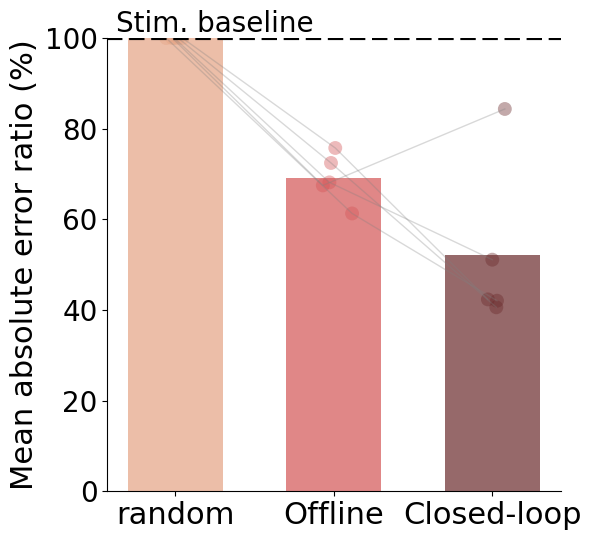

In [6]:
# Example usage:
if __name__ == "__main__":
    
    colors = ['#e5a383', '#d45455', '#6a2a2b', '#b83f5b', '#f5768d']
    x_labels = ['random', 'Offline', 'Closed-loop']
    
    fig, ax = plot_grouped_results(x_labels, xlabel='', ylabel='Mean absolute error ratio (%)', bar_data=relative_errors, 
                                   colors=colors, 
                                   ylim=(0, 100), 
                                   save_path="/home/ldy/Closed_loop_optimizing/plots/Heuristic_generation/bar_performance.png")
    

In [7]:
np.asarray(relative_errors).shape

(3, 5)

In [8]:


# def plot_grouped_results(x_labels, bar_data, colors=None, ylim=(0, 100), 
#                          xlabel='Step', ylabel='Similarity', figsize=(6, 6), save_path=""):
#     """
#     Plot grouped results with semi-transparent data points showing distribution.
    
#     Parameters:
#     - x_labels: List of labels for the x-axis
#     - bar_data: List of lists containing the results for each group
#     - colors: List of colors for each bar (optional)
#     - ylim: Tuple specifying y-axis limits (default: (0.4, 1.0))
#     - xlabel: Label for x-axis (default: 'Step')
#     - ylabel: Label for y-axis (default: 'Similarity')
#     - figsize: Figure size (default: (8, 6))
#     """
#     # Calculate statistics
#     means = [np.mean(group) for group in bar_data]
    
#     # Set default colors if not provided
#     if colors is None:
#         colors = ['#e5a383', '#d45455', '#6a2a2b', '#b83f5b', '#f5768d']
    
#     # Create figure
#     fig, ax = plt.subplots(figsize=figsize)
    
#     # Plot bars
#     bars = ax.bar(x_labels, means, color=colors[:len(x_labels)], width=0.6, alpha=0.7)
    
#     # Plot individual data points with jitter and transparency
#     for i, group in enumerate(bar_data):
#         # Add jitter to x-position
#         x_jitter = np.random.normal(i, 0.05, size=len(group))
#         ax.scatter(x_jitter, group, color=colors[i], alpha=0.4, s=100, edgecolor='none')
    
#     # Add horizontal dashed line at first bar's y-value
#     stim_baseline = means[0]
#     ax.axhline(y=stim_baseline, color='black', linestyle='--', linewidth=1.5)
    
#     # Modify y-ticks to show percentages (multiplied by 100)
#     yticks = ax.get_yticks()
#     ax.set_yticklabels([f'{int(y)}' for y in yticks], fontsize=20)
    
#     # Set y-axis limits (still in original scale, but labels show *100)
#     plt.ylim(*ylim)
    
#     # Add label for the dashed line (now using the original y-scale)
#     ax.text(0.02, stim_baseline + 0.01, 'Stim. baseline', 
#             transform=ax.get_yaxis_transform(), 
#             fontsize=20, color='black', va='bottom')
    
#     plt.xticks(fontsize=22)
    
#     # Remove right and top spines
#     ax.spines['right'].set_visible(False)
#     ax.spines['top'].set_visible(False)
    
#     # Add "T=10 epochs" label in upper right corner
#     ax.text(0.88, 0.92, 'N=5 Targets', 
#             transform=ax.transAxes,
#             fontsize=20, color='black',
#             ha='right', va='top')
    
#     # Add labels
#     plt.xlabel(xlabel, fontsize=29)
#     plt.ylabel(ylabel, fontsize=26)
    
#     if save_path:
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')

    
#     # Adjust layout and show
#     plt.tight_layout()
#     plt.show()
#     return fig, ax


In [9]:
def plot_grouped_results(x_labels, bar_data, colors=None, ylim=(0, 100), 
                         xlabel='Step', ylabel='Similarity', figsize=(6, 5.5), n_groups=0, save_path=""):
    """
    Plot grouped results with semi-transparent data points showing distribution
    and connecting lines for same targets across groups.
    
    Parameters:
    - x_labels: List of labels for the x-axis
    - bar_data: List of lists containing the results for each group
    - colors: List of colors for each bar (optional)
    - ylim: Tuple specifying y-axis limits (default: (0.4, 1.0))
    - xlabel: Label for x-axis (default: 'Step')
    - ylabel: Label for y-axis (default: 'Similarity')
    - figsize: Figure size (default: (8, 6))
    """
    # Calculate statistics
    means = [np.mean(group) for group in bar_data]
    
    # Set default colors if not provided
    if colors is None:
        colors = ['#e5a383', '#d45455', '#6a2a2b', '#b83f5b', '#f5768d']
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot bars
    bars = ax.bar(x_labels, means, color=colors[:len(x_labels)], width=0.6, alpha=0.7)
    
    # First plot individual data points with jitter and transparency
    all_points = []
    for i, group in enumerate(bar_data):
        # Add jitter to x-position
        x_jitter = np.random.normal(i, 0.05, size=len(group))
        points = ax.scatter(x_jitter, group, color=colors[i], alpha=0.4, s=100, edgecolor='none')
        all_points.append((x_jitter, group))
    
    # Connect points from the same target across groups with gray lines
    # Assuming each group has the same number of points (one per target)
    num_targets = len(bar_data[0])
    for target_idx in range(num_targets):
        # Get the x and y coordinates for this target across all groups
        x_coords = [all_points[group_idx][0][target_idx] for group_idx in range(len(bar_data))]
        y_coords = [all_points[group_idx][1][target_idx] for group_idx in range(len(bar_data))]
        ax.plot(x_coords, y_coords, color='gray', alpha=0.3, linewidth=1, linestyle='-')
    
    # Add horizontal dashed line at first bar's y-value
    stim_baseline = means[0]
    ax.axhline(y=stim_baseline, color='black', linestyle='--', linewidth=3)
    
    # Modify y-ticks to show percentages (multiplied by 100)
    yticks = ax.get_yticks()
    ax.set_yticklabels([f'{int(y)}' for y in yticks], fontsize=20)
    
    # Set y-axis limits (still in original scale, but labels show *100)
    plt.ylim(*ylim)
    
    # Add label for the dashed line (now using the original y-scale)
    ax.text(0.02, stim_baseline + 0.01, 'Stim. baseline', 
            transform=ax.get_yaxis_transform(), 
            fontsize=20, color='black', va='bottom')
    
    plt.xticks(fontsize=22)
    
    # Remove right and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    # Add "T=10 epochs" label in upper right corner
    # ax.text(0.88, 0.92, f'N={n_groups} groups', 
    #         transform=ax.transAxes,
    #         fontsize=20, color='black',
    #         ha='right', va='top')
    
    # Add labels
    plt.xlabel(xlabel, fontsize=29)
    plt.ylabel(ylabel, fontsize=22)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    # Adjust layout and show
    plt.tight_layout()
    plt.show()
    return fig, ax

/tmp/ipykernel_2690884/1176329886.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(y)}' for y in yticks], fontsize=20)


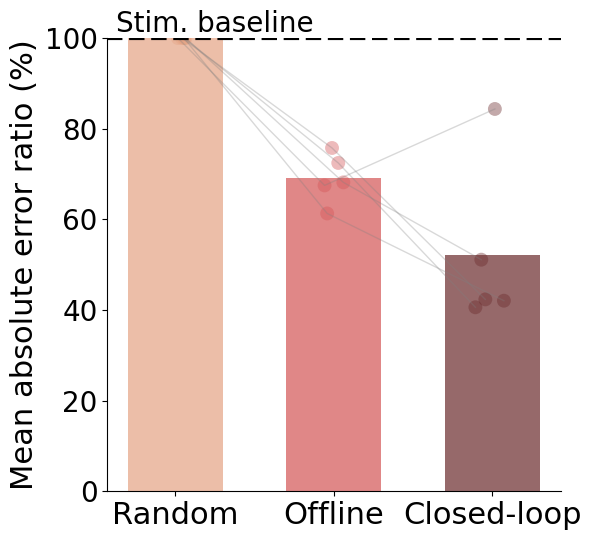

In [10]:

# Example usage:
if __name__ == "__main__":
    # Example data (replace with your actual data)

    
    colors = ['#e5a383', '#d45455', '#6a2a2b', '#b83f5b', '#f5768d']
    x_labels = ['Random', 'Offline', 'Closed-loop']
    
    fig, ax = plot_grouped_results(x_labels, 
                                  xlabel='', 
                                  ylabel='Mean absolute error ratio (%)', 
                                  bar_data=relative_errors, 
                                  colors=colors, 
                                  ylim=(0, 100), 
                                  save_path="/home/ldy/Closed_loop_optimizing/Heuristic_generation/plots/bar_performance.png")